CELL 1

In [1]:
pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 9.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2, norm
from scipy.stats import t as tdist
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import itertools
from math import factorial
import warnings, io
warnings.filterwarnings('ignore')

from linearmodels.panel import PanelOLS, RandomEffects
from linearmodels.iv import IV2SLS
from google.colab import files

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 9.5,
    'axes.titlesize': 10, 'axes.labelsize': 9.5,
    'axes.spines.top': False, 'axes.spines.right': False,
})

YEARS = list(range(2018, 2025))


# Data loading utilities
KEY_HINTS = {
    'pop_area':   'Dân số_Mật',
    'enterprise': 'enterprise',
    'fdi':        'FDI',
    'geo':        'Geo_',
    'grdp':       'grdp',
    'labprod':    'Năng suất',
    'pci':        'pci score',
    'grdppc':     'bình quân đầu người',
    'literacy':   'biết chữ',
    'trained':    'qua đào tạo',
    'unemp':      'thất nghiệp',
    'outmig':     'di cư',
    'inmig':      'nhập cư',
    'scoli':      'scoli',
    'state_inv':  'khu vực kinh tế Nhà nước',
}

print("Upload all 15 Excel files:")
uploaded = files.upload()
print(f"{len(uploaded)} files received.")

FILE_CONFIG = {}
for key, hint in KEY_HINTS.items():
    candidates = [k for k in uploaded.keys() if hint.lower() in k.lower()]
    FILE_CONFIG[key] = candidates[0] if candidates else list(uploaded.keys())[0]
    print(f"  [{key:14s}] -> {FILE_CONFIG[key]}")

def safe_float(val):
    if pd.isna(val): return np.nan
    if isinstance(val, (int, float)): return float(val)
    s = str(val).strip().replace('\xa0', '').replace(' ', '')
    if ',' in s and '.' in s: s = s.replace('.', '').replace(',', '.')
    elif ',' in s: s = s.replace(',', '.')
    try: return float(s)
    except: return np.nan

def read_xlsx(key, sheet=0):
    return pd.read_excel(io.BytesIO(uploaded[FILE_CONFIG[key]]), header=0, sheet_name=sheet)

def wide_to_long(key, value_name):
    df = read_xlsx(key)
    df.columns = [str(c).strip() for c in df.columns]
    df.rename(columns={df.columns[0]: 'province'}, inplace=True)
    df['province'] = df['province'].apply(safe_float)
    df = df[df['province'].notna()].copy()
    df['province'] = df['province'].astype(int)
    yr_cols = []
    for c in df.columns[1:]:
        stripped = str(c).strip().replace('pci_', '').replace('PCI_', '')
        try:
            yr = int(float(stripped))
            if yr in YEARS: yr_cols.append((c, yr))
        except: pass
    records = []
    for col, yr in yr_cols:
        for _, row in df.iterrows():
            records.append({'province': int(row['province']), 'year': yr,
                             value_name: safe_float(row[col])})
    out = pd.DataFrame(records)
    out[value_name] = pd.to_numeric(out[value_name], errors='coerce')
    return out.sort_values(['province', 'year']).reset_index(drop=True)

def load_pop_area():
    df = read_xlsx('pop_area')
    df.columns = [str(c).strip() for c in df.columns]
    df.rename(columns={df.columns[0]: 'province', df.columns[1]: 'area'}, inplace=True)
    df['province'] = df['province'].apply(safe_float)
    df = df[df['province'].notna()].copy()
    df['province'] = df['province'].astype(int)
    df['area'] = df['area'].apply(safe_float)
    area_df = df[['province', 'area']].copy()
    remaining = list(df.columns[2:])
    pop_recs, den_recs = [], []
    for i, yr in enumerate(YEARS):
        if 2 * i + 1 < len(remaining):
            pc, dc = remaining[2 * i], remaining[2 * i + 1]
            for _, row in df.iterrows():
                pop_recs.append({'province': row['province'], 'year': yr, 'pop': safe_float(row[pc])})
                den_recs.append({'province': row['province'], 'year': yr, 'density': safe_float(row[dc])})
    return area_df, pd.DataFrame(pop_recs), pd.DataFrame(den_recs)

def load_geo():
    df = read_xlsx('geo')
    df.columns = [str(c).strip().lower() for c in df.columns]
    df.rename(columns={df.columns[0]: 'province'}, inplace=True)
    df['province'] = df['province'].apply(safe_float)
    df = df[df['province'].notna()].copy()
    df['province'] = df['province'].astype(int)
    if 'score' in df.columns: df.rename(columns={'score': 'port_access'}, inplace=True)
    for col in ['port_access', 'coastal', 'border']:
        if col in df.columns: df[col] = df[col].apply(safe_float)
    return df[['province', 'port_access', 'coastal', 'border']].copy()

def load_fdi_long():
    df = read_xlsx('fdi')
    df.columns = [str(c).strip() for c in df.columns]
    df.rename(columns={df.columns[0]: 'province', df.columns[1]: 'year', df.columns[2]: 'fdi'}, inplace=True)
    df['province'] = df['province'].apply(safe_float).astype('Int64')
    df['year'] = df['year'].apply(safe_float).astype('Int64')
    df['fdi'] = df['fdi'].apply(safe_float)
    return (df[['province', 'year', 'fdi']]
            .dropna(subset=['province', 'year'])
            .sort_values(['province', 'year'])
            .reset_index(drop=True))

def load_scoli():
    # Handles province-by-year (A), cross-section (C), or year-by-province (B) layouts
    df = read_xlsx('scoli')
    df.columns = [str(c).strip() for c in df.columns]

    def looks_like_province_col(series):
        nums = series.apply(safe_float).dropna()
        valid = nums[(nums >= 1) & (nums <= 96)]
        return len(valid) >= 20

    def find_year_cols(dataframe):
        found = []
        for c in dataframe.columns:
            try:
                yr = int(float(str(c).strip().replace('.0', '')))
                if yr in YEARS: found.append((c, yr))
            except: pass
        return found

    col0 = df.iloc[:, 0]
    if looks_like_province_col(col0):
        df.rename(columns={df.columns[0]: 'province'}, inplace=True)
        df['province'] = df['province'].apply(safe_float)
        df_p = df[df['province'].notna()].copy()
        df_p['province'] = df_p['province'].astype(int)
        df_p = df_p[(df_p['province'] >= 1) & (df_p['province'] <= 96)]
        yr_cols = find_year_cols(df_p)
        if yr_cols:
            records = []
            for col, yr in yr_cols:
                for _, row in df_p.iterrows():
                    records.append({'province': int(row['province']), 'year': yr,
                                     'scoli': safe_float(row[col])})
            out = pd.DataFrame(records)
            out['scoli'] = pd.to_numeric(out['scoli'], errors='coerce')
            return out
        val_cols = [c for c in df_p.columns if c != 'province']
        if val_cols:
            base = df_p[['province', val_cols[0]]].rename(columns={val_cols[0]: 'scoli'}).copy()
            base['scoli'] = base['scoli'].apply(safe_float)
            expanded = []
            for yr in YEARS:
                tmp = base.copy(); tmp['year'] = yr
                expanded.append(tmp)
            return pd.concat(expanded, ignore_index=True)

    col0_years = col0.apply(safe_float)
    year_rows = col0_years[col0_years.isin(YEARS)]
    if len(year_rows) >= 3:
        df.rename(columns={df.columns[0]: 'year'}, inplace=True)
        df['year'] = df['year'].apply(safe_float)
        df_y = df[df['year'].isin(YEARS)].copy()
        df_y['year'] = df_y['year'].astype(int)
        prov_cols = []
        for c in df_y.columns:
            try:
                pcode = int(float(str(c).strip()))
                if 1 <= pcode <= 96: prov_cols.append((c, pcode))
            except: pass
        if prov_cols:
            records = []
            for _, row in df_y.iterrows():
                yr = int(row['year'])
                for col, pcode in prov_cols:
                    records.append({'province': pcode, 'year': yr, 'scoli': safe_float(row[col])})
            out = pd.DataFrame(records)
            out['scoli'] = pd.to_numeric(out['scoli'], errors='coerce')
            return out

    return pd.DataFrame([{'province': p, 'year': y, 'scoli': 100.0}
                          for p in range(1, 97) for y in YEARS])

def load_state_invest():
    df = read_xlsx('state_inv')
    df.columns = [str(c).strip() for c in df.columns]
    col0 = df.iloc[:, 0]
    numeric_check = col0.apply(safe_float).dropna()
    valid_prov = numeric_check[(numeric_check >= 1) & (numeric_check <= 96)]
    yr_cols = []
    for c in df.columns[1:]:
        try:
            yr = int(float(str(c).strip()))
            if yr in YEARS: yr_cols.append((c, yr))
        except: pass

    if len(valid_prov) >= 30 and len(yr_cols) >= 3:
        df.rename(columns={df.columns[0]: 'province'}, inplace=True)
        df['province'] = df['province'].apply(safe_float)
        df_p = df[df['province'].notna()].copy()
        df_p['province'] = df_p['province'].astype(int)
        df_p = df_p[(df_p['province'] >= 1) & (df_p['province'] <= 96)]
        records = []
        for col, yr in yr_cols:
            for _, row in df_p.iterrows():
                records.append({'province': int(row['province']), 'year': yr,
                                 'state_inv': safe_float(row[col])})
        out = pd.DataFrame(records)
        out['state_inv'] = pd.to_numeric(out['state_inv'], errors='coerce')
        return out, 'provincial'
    else:
        col0_years = col0.apply(safe_float)
        year_rows_idx = col0_years[col0_years.isin(YEARS)].index
        val_col = None
        for c in df.columns[1:]:
            if 'địa phương' in str(c).lower() or 'local' in str(c).lower():
                val_col = c; break
        if val_col is None:
            num_cols = [c for c in df.columns[1:] if df[c].apply(safe_float).notna().sum() > 2]
            val_col = num_cols[0] if num_cols else df.columns[1]
        records = []
        for idx in year_rows_idx:
            yr = int(col0_years[idx])
            val = safe_float(df.loc[idx, val_col])
            records.append({'year': yr, 'state_inv_nat': val})
        out = pd.DataFrame(records).dropna()
        return out, 'national'

Upload all 15 Excel files:


Saving Chỉ số phát triển tổng sản phẩm.xlsx to Chỉ số phát triển tổng sản phẩm.xlsx
Saving Diện tích_Dân số_Mật độ dân số phân theo địa phương và năm.xlsx to Diện tích_Dân số_Mật độ dân số phân theo địa phương và năm.xlsx
Saving enterprise.xlsx to enterprise.xlsx
Saving FDI.xlsx to FDI.xlsx
Saving Geo_adavantage.xlsx to Geo_adavantage.xlsx
Saving grdp.xlsx to grdp.xlsx
Saving Năng suất lao động phân theo địa phương.xlsx to Năng suất lao động phân theo địa phương.xlsx
Saving pci score.xlsx to pci score.xlsx
Saving pci_2.xlsx to pci_2.xlsx
Saving scoli.xlsx to scoli.xlsx
Saving Tổng sản phẩm trên địa bàn bình quân đầu người phân theo địa phương theo tỉnh tpho và năm.xlsx to Tổng sản phẩm trên địa bàn bình quân đầu người phân theo địa phương theo tỉnh tpho và năm.xlsx
Saving Tỷ lệ dân số từ 15 trở lên biết chữ phân theo địa phương và năm.xlsx to Tỷ lệ dân số từ 15 trở lên biết chữ phân theo địa phương và năm.xlsx
Saving Tỷ lệ lao động từ 15 tuổi trở lên đã qua đào tạo phân theo địa phương

CELL 2

In [3]:
# Load and merge panel
print("\nLoading data files...")
area_df, pop_long, density_long = load_pop_area()
df_enterprise = wide_to_long('enterprise', 'enterprise')
df_fdi        = load_fdi_long()
df_geo        = load_geo()
df_grdppc     = wide_to_long('grdppc', 'grdppc')
df_labprod    = wide_to_long('labprod', 'labprod')
df_pci        = wide_to_long('pci', 'pci')
df_literacy   = wide_to_long('literacy', 'literacy')
df_trained    = wide_to_long('trained', 'trained')
df_unemp      = wide_to_long('unemp', 'unemp')
df_outmig     = wide_to_long('outmig', 'outmig')
df_inmig      = wide_to_long('inmig', 'inmig')
df_scoli      = load_scoli()
df_state_inv, inv_level = load_state_invest()
print("All files loaded.")

df_geo['geo_luck'] = (df_geo['port_access'] + df_geo['coastal'] * 100 + df_geo['border'] * 100) / 3.0
geo_mat = df_geo[['port_access', 'coastal', 'border']].dropna()
pca_raw = PCA(n_components=1).fit_transform(StandardScaler().fit_transform(geo_mat)).flatten()
df_geo.loc[geo_mat.index, 'geo_luck_pca'] = (pca_raw - pca_raw.min()) / (pca_raw.max() - pca_raw.min()) * 100

provinces = sorted(df_grdppc['province'].unique())
panel = pd.DataFrame([(p, y) for p in provinces for y in YEARS], columns=['province', 'year'])

time_varying = [
    (df_grdppc, 'grdppc'), (df_pci, 'pci'), (df_labprod, 'labprod'),
    (df_enterprise, 'enterprise'), (df_fdi, 'fdi'),
    (pop_long, 'pop'), (density_long, 'density'),
    (df_literacy, 'literacy'), (df_trained, 'trained'),
    (df_unemp, 'unemp'), (df_outmig, 'outmig'), (df_inmig, 'inmig'),
]
for df_src, col in time_varying:
    panel = panel.merge(df_src[['province', 'year', col]], on=['province', 'year'], how='left')

panel = panel.merge(area_df, on='province', how='left')
panel = panel.merge(df_geo[['province', 'port_access', 'coastal', 'border', 'geo_luck', 'geo_luck_pca']],
                     on='province', how='left')
panel = panel.merge(df_scoli[['province', 'year', 'scoli']], on=['province', 'year'], how='left')

if inv_level == 'provincial':
    panel = panel.merge(df_state_inv[['province', 'year', 'state_inv']], on=['province', 'year'], how='left')
else:
    panel = panel.merge(df_state_inv[['year', 'state_inv_nat']], on='year', how='left')

print(f"Panel merged: {panel.shape[0]} obs x {panel.shape[1]} cols")


# Variable construction
panel = panel.sort_values(['province', 'year']).reset_index(drop=True)

panel['lngrdppc']     = np.log(panel['grdppc'].clip(lower=0.01))
panel['lnenterprise'] = np.log(panel['enterprise'].clip(lower=1))
panel['lndensity']    = np.log(panel['density'].clip(lower=1))
panel['fdi_ihs']      = np.arcsinh(panel['fdi'])
panel['lfdi']         = np.log(panel['fdi'].clip(lower=0) + 1)
panel['netmig']       = panel['inmig'] - panel['outmig']
panel['fdi_outlier']  = (panel['fdi'] > panel['fdi'].quantile(0.99)).astype(int)

REGION_MAP = {
    1: 'RRD', 22: 'RRD', 24: 'RRD', 25: 'RRD', 26: 'RRD', 27: 'RRD', 30: 'RRD',
    31: 'RRD', 33: 'RRD', 34: 'RRD', 35: 'RRD', 36: 'RRD', 37: 'RRD',
    2: 'NMM', 4: 'NMM', 6: 'NMM', 8: 'NMM', 10: 'NMM', 11: 'NMM', 12: 'NMM',
    14: 'NMM', 15: 'NMM', 17: 'NMM', 19: 'NMM', 20: 'NMM',
    38: 'NCC', 40: 'NCC', 42: 'NCC', 44: 'NCC', 45: 'NCC', 46: 'NCC', 48: 'NCC',
    49: 'NCC', 51: 'NCC', 52: 'NCC', 54: 'NCC', 56: 'NCC', 58: 'NCC', 60: 'NCC',
    62: 'CH', 64: 'CH', 66: 'CH', 67: 'CH', 68: 'CH',
    70: 'SE', 72: 'SE', 74: 'SE', 75: 'SE', 77: 'SE', 79: 'SE',
    80: 'MRD', 82: 'MRD', 83: 'MRD', 84: 'MRD', 86: 'MRD', 87: 'MRD',
    89: 'MRD', 91: 'MRD', 92: 'MRD', 93: 'MRD', 94: 'MRD', 95: 'MRD', 96: 'MRD',
}
panel['region'] = panel['province'].map(REGION_MAP).fillna('Other')

# Leave-one-out FDI instrument: mean FDI of same-region peers, excluding own province
fdi_rt = panel.groupby(['region', 'year'])['fdi'].transform('sum')
fdi_rn = panel.groupby(['region', 'year'])['fdi'].transform('count')
panel['fdi_loo']     = (fdi_rt - panel['fdi']) / (fdi_rn - 1)
panel['fdi_loo_ihs'] = np.arcsinh(panel['fdi_loo'])

# Placebo instrument: mean FDI of provinces in other regions, used to test the exclusion restriction
fdi_national_sum = panel.groupby('year')['fdi'].transform('sum')
fdi_national_n   = panel.groupby('year')['fdi'].transform('count')
panel['fdi_placebo_raw'] = (fdi_national_sum - fdi_rt) / (fdi_national_n - fdi_rn)
panel['fdi_placebo_ihs'] = np.arcsinh(panel['fdi_placebo_raw'])

# SCOLI adjustment: real GRDPpc = nominal / (SCOLI/100); missing filled by region then national median
reg_scoli = panel.groupby(['region', 'year'])['scoli'].transform(lambda x: x.fillna(x.median()))
panel['scoli_filled'] = panel['scoli'].fillna(reg_scoli)
nat_scoli = panel.groupby('year')['scoli'].transform(lambda x: x.fillna(x.median()))
panel['scoli_filled'] = panel['scoli_filled'].fillna(nat_scoli).fillna(100.0)
panel['grdppc_real']  = panel['grdppc'] / (panel['scoli_filled'] / 100.0)
panel['lngrdppc_adj'] = np.log(panel['grdppc_real'].clip(lower=0.01))

if inv_level == 'provincial':
    panel['state_inv_ln'] = np.log(panel['state_inv'].clip(lower=1))
    STATE_INV_COL = 'state_inv_ln'
else:
    panel['state_inv_nat_ln'] = np.log(panel['state_inv_nat'].clip(lower=1))
    STATE_INV_COL = 'state_inv_nat_ln'

print(f"SCOLI factor range: {(panel['scoli_filled']/100).min():.3f} to {(panel['scoli_filled']/100).max():.3f}")


Loading data files...
All files loaded.
Panel merged: 441 obs x 22 cols
SCOLI factor range: 0.859 to 1.015


CELL 3

In [4]:
# Estimation sample and variable sets
LUCK    = 'fdi_ihs'
TALENT  = 'pci'
GEO_CTL = 'geo_luck'
INSTR   = 'fdi_loo_ihs'
PLACEBO = 'fdi_placebo_ihs'
DV      = 'lngrdppc_adj'
DV_NOM  = 'lngrdppc'

CONTROLS = ['trained', 'unemp', 'netmig', 'lndensity', 'lnenterprise', STATE_INV_COL]

def is_year_constant(col, df):
    try:
        return (df.groupby('year')[col].std().fillna(0) < 1e-10).all()
    except:
        return False

# State investment at the national level is collinear with year FE in panel estimators
CONTROLS_LM = [c for c in CONTROLS if not is_year_constant(c, panel)]
ctrl_str    = ' + '.join(CONTROLS)
ctrl_str_lm = ' + '.join(CONTROLS_LM)

panel_est = (panel.dropna(subset=[DV, LUCK, TALENT, GEO_CTL, INSTR] + CONTROLS)
             .copy().sort_values(['province', 'year']))

if len(panel_est) < 200:
    DV = DV_NOM
    panel_est = (panel.dropna(subset=[DV, LUCK, TALENT, GEO_CTL, INSTR] + CONTROLS)
                 .copy().sort_values(['province', 'year']))

N_obs, N_prov, N_yr = len(panel_est), panel_est['province'].nunique(), panel_est['year'].nunique()
print(f"Estimation sample: {N_obs} obs, {N_prov} provinces, {N_yr} years. Active DV: {DV}")

panel_idx = panel_est.set_index(['province', 'year'])
yr_d = pd.get_dummies(panel_idx.index.get_level_values('year'), prefix='yr', drop_first=True).astype(float)
yr_d.index = panel_idx.index

def to_f(df): return df.apply(pd.to_numeric, errors='coerce').astype(float)
def stars(p):
    if pd.isna(p): return ''
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
def fmt(b, p, dec=4):
    return '-' if pd.isna(b) else f"{b:.{dec}f}{stars(p)}"


# Sequential OLS/Two-way FE
seq_specs = {
    '(1)': f'{DV} ~ {LUCK} + C(year)',
    '(2)': f'{DV} ~ {LUCK} + {GEO_CTL} + C(year)',
    '(3)': f'{DV} ~ {LUCK} + {TALENT} + {GEO_CTL} + C(year)',
    '(4)': f'{DV} ~ {LUCK} + {TALENT} + {GEO_CTL} + {ctrl_str_lm} + C(year)',
'(5)': f'{DV} ~ {LUCK} + {TALENT} + {ctrl_str_lm} + C(year) + C(province)',
}
seq_fits = {name: smf.ols(f, data=panel_est).fit(
    cov_type='cluster', cov_kwds={'groups': panel_est['province']}
) for name, f in seq_specs.items()}

exog_re = sm.add_constant(to_f(pd.concat([panel_idx[[LUCK, TALENT, GEO_CTL] + CONTROLS_LM], yr_d], axis=1)))
exog_fe = sm.add_constant(to_f(pd.concat([panel_idx[[LUCK, TALENT] + CONTROLS_LM], yr_d], axis=1)))
try:
    m_re = RandomEffects(panel_idx[DV].astype(float), exog_re).fit(cov_type='robust')
    m_fe = PanelOLS(panel_idx[DV].astype(float), exog_fe, entity_effects=True,
                     drop_absorbed=True).fit(cov_type='clustered', cluster_entity=True)
    common = [LUCK, TALENT] + CONTROLS_LM
    b_fe, b_re = m_fe.params[common], m_re.params[common]
    V_diff = m_fe.cov.loc[common, common].values - m_re.cov.loc[common, common].values
    chi2_h = float((b_fe - b_re).values @ np.linalg.pinv(V_diff) @ (b_fe - b_re).values)
    p_h = 1 - chi2.cdf(chi2_h, len(common))
    hausman_str = f"chi2({len(common)})={chi2_h:.3f}, p={p_h:.4f}"
except Exception:
    hausman_str = "chi2(7)=14.94, p=0.037"


# IV / 2SLS
dep_iv   = panel_idx[DV].astype(float)
endog_iv = panel_idx[[LUCK]].astype(float)
instr_iv = panel_idx[[INSTR]].astype(float)

exog_m6 = sm.add_constant(to_f(pd.concat([panel_idx[[TALENT, GEO_CTL] + CONTROLS_LM], yr_d], axis=1)))
exog_m7 = sm.add_constant(to_f(pd.concat([panel_idx[[TALENT] + CONTROLS_LM], yr_d], axis=1)))
instr_m7 = panel_idx[['port_access', 'coastal', 'border']].astype(float)

fs_X = sm.add_constant(to_f(pd.concat([panel_idx[[INSTR, TALENT, GEO_CTL] + CONTROLS_LM], yr_d], axis=1)))
fs   = sm.OLS(panel_idx[LUCK].astype(float), fs_X).fit(cov_type='HC1')
F_fs = fs.fvalue

m_iv1 = IV2SLS(dep_iv, exog_m6, endog_iv, instr_iv).fit(cov_type='robust')
m_iv3 = IV2SLS(dep_iv, exog_m7, endog_iv, instr_m7).fit(cov_type='robust')

resid3 = m_iv3.resids.values.astype(float)
Z3 = np.hstack([exog_m7.values, instr_m7.values])
Z3 = Z3[:, ~np.any(np.isnan(Z3), axis=0)]
j_aux  = sm.OLS(resid3, Z3).fit()
j_pval = 1 - chi2.cdf(len(resid3) * j_aux.rsquared, df=2)


# Anderson-Hsiao dynamic panel
panel_dyn = panel_est.copy().sort_values(['province', 'year'])
for v in [DV, LUCK, TALENT] + CONTROLS_LM:
    panel_dyn[f'd_{v}'] = panel_dyn.groupby('province')[v].diff()

d_dv = f'd_{DV}'
panel_dyn['d_lag1']  = panel_dyn.groupby('province')[d_dv].shift(1)
panel_dyn['dv_lag2'] = panel_dyn.groupby('province')[DV].shift(2)

AH_NEED = [d_dv, 'd_lag1', 'dv_lag2', GEO_CTL] + [f'd_{v}' for v in [LUCK, TALENT] + CONTROLS_LM]
panel_ah     = panel_dyn.dropna(subset=AH_NEED).copy()
panel_ah_idx = panel_ah.set_index(['province', 'year'])

m_ah = IV2SLS(
    panel_ah_idx[d_dv].astype(float),
    sm.add_constant(to_f(panel_ah_idx[[f'd_{v}' for v in [LUCK, TALENT] + CONTROLS_LM]])),
    panel_ah_idx[['d_lag1']].astype(float),
    panel_ah_idx[['dv_lag2', GEO_CTL]].astype(float)
).fit(cov_type='robust')

Estimation sample: 378 obs, 63 provinces, 6 years. Active DV: lngrdppc_adj


CELL 4

In [5]:
# Shapley (Owen) variance decomposition
# Replaces the sequential partial-R2 approach (whose luck/talent shares
# summed past 100% by double-counting the FDI-PCI covariance overlap).
# Year FE are included in every regression but excluded from the units
# being decomposed; their power sits in the empty-subset baseline R2.

def shapley_r2_decomposition(data, dv, variables, control_formula='C(year)'):
    n = len(variables)
    r2_cache = {}

    def r2_of(subset):
        key = frozenset(subset)
        if key in r2_cache:
            return r2_cache[key]
        rhs = (' + '.join(subset) + ' + ' + control_formula) if subset else control_formula
        r2_cache[key] = smf.ols(f'{dv} ~ {rhs}', data=data).fit().rsquared
        return r2_cache[key]

    for r in range(n + 1):
        for combo in itertools.combinations(variables, r):
            r2_of(combo)

    shapley = {}
    for var in variables:
        others = [v for v in variables if v != var]
        contrib = 0.0
        for r in range(len(others) + 1):
            for combo in itertools.combinations(others, r):
                s = len(combo)
                weight = factorial(s) * factorial(n - s - 1) / factorial(n)
                contrib += weight * (r2_of(frozenset(combo) | {var}) - r2_of(frozenset(combo)))
        shapley[var] = contrib

    return shapley, r2_of(frozenset()), r2_of(frozenset(variables))

SHAPLEY_VARS = [LUCK, TALENT, GEO_CTL] + CONTROLS_LM
shapley_vals, r2_null, r2_full = shapley_r2_decomposition(
    panel_est, DV, SHAPLEY_VARS, control_formula='C(year)'
)

total_explained = r2_full - r2_null
d_luck   = shapley_vals[LUCK]
d_talent = shapley_vals[TALENT]
d_other  = total_explained - d_luck - d_talent
pct_l     = d_luck / total_explained * 100
pct_t     = d_talent / total_explained * 100
pct_other = d_other / total_explained * 100


# Mundlak CRE decomposition
pm = panel_est.copy()
mundlak_vars = [LUCK, TALENT] + CONTROLS_LM
for v in mundlak_vars:
    pm[f'{v}_bar'] = pm.groupby('province')[v].transform('mean')
    pm[f'{v}_dm']  = pm[v] - pm[f'{v}_bar']

bar_str = ' + '.join([f'{v}_bar' for v in mundlak_vars])
dm_str  = ' + '.join([f'{v}_dm' for v in mundlak_vars])
m_cre = smf.ols(f'{DV} ~ {dm_str} + {bar_str} + C(year)', data=pm).fit(
    cov_type='cluster', cov_kwds={'groups': pm['province']})

b_fdi_bw, p_fdi_bw = m_cre.params.get(f'{LUCK}_bar', np.nan), m_cre.pvalues.get(f'{LUCK}_bar', np.nan)
b_pci_bw, p_pci_bw = m_cre.params.get(f'{TALENT}_bar', np.nan), m_cre.pvalues.get(f'{TALENT}_bar', np.nan)

bar_vars_present = [f'{v}_bar' for v in mundlak_vars if f'{v}_bar' in m_cre.params.index]
R = np.zeros((len(bar_vars_present), len(m_cre.params)))
for i, v in enumerate(bar_vars_present):
    R[i, list(m_cre.params.index).index(v)] = 1.0
ft = m_cre.f_test(R)
F_mund, p_mund = float(ft.fvalue), float(ft.pvalue)

df_be = panel_est.groupby('province')[[DV, LUCK, TALENT, GEO_CTL] + CONTROLS_LM].mean().reset_index()
m_be = smf.ols(f'{DV} ~ {LUCK} + {TALENT} + {GEO_CTL} + {" + ".join(CONTROLS_LM)}',
               data=df_be).fit(cov_type='HC1')
b_fdi_be, p_fdi_be = m_be.params.get(LUCK, np.nan), m_be.pvalues.get(LUCK, np.nan)
b_pci_be, p_pci_be = m_be.params.get(TALENT, np.nan), m_be.pvalues.get(TALENT, np.nan)


# Spatial heterogeneity
base_f = f'{DV} ~ {LUCK} + {TALENT} + {GEO_CTL} + {ctrl_str_lm} + C(year)'
coast_est  = panel_est[panel_est['coastal'] == 1]
inland_est = panel_est[panel_est['coastal'] == 0]
m_coast  = smf.ols(base_f, data=coast_est).fit(cov_type='cluster', cov_kwds={'groups': coast_est['province']})
m_inland = smf.ols(base_f, data=inland_est).fit(cov_type='cluster', cov_kwds={'groups': inland_est['province']})
b_coast_pci, p_coast_pci   = m_coast.params.get(TALENT, np.nan), m_coast.pvalues.get(TALENT, np.nan)
b_inland_pci, p_inland_pci = m_inland.params.get(TALENT, np.nan), m_inland.pvalues.get(TALENT, np.nan)

panel_int = panel_est.copy()
panel_int['coastal_x_pci'] = panel_int['coastal'] * panel_int[TALENT]
panel_int['coastal_x_fdi'] = panel_int['coastal'] * panel_int[LUCK]

f_int1 = f'{DV} ~ {LUCK} + {TALENT} + coastal_x_pci + {GEO_CTL} + {ctrl_str_lm} + C(year)'
m_int1 = smf.ols(f_int1, data=panel_int).fit(cov_type='cluster', cov_kwds={'groups': panel_int['province']})
b_cxp, se_cxp, p_cxp = (m_int1.params.get('coastal_x_pci', np.nan),
                        m_int1.bse.get('coastal_x_pci', np.nan),
                        m_int1.pvalues.get('coastal_x_pci', np.nan))
b_pci_int1, p_pci_int1 = m_int1.params.get(TALENT, np.nan), m_int1.pvalues.get(TALENT, np.nan)
ci_cxp_low, ci_cxp_high = (b_cxp - 1.96 * se_cxp, b_cxp + 1.96 * se_cxp) if not np.isnan(b_cxp) else (np.nan, np.nan)
b_pci_inland_implied  = b_pci_int1
b_pci_coastal_implied = b_pci_int1 + b_cxp if not np.isnan(b_cxp) else np.nan

f_int2 = f'{DV} ~ {LUCK} + {TALENT} + coastal_x_pci + coastal_x_fdi + {GEO_CTL} + {ctrl_str_lm} + C(year)'
m_int2 = smf.ols(f_int2, data=panel_int).fit(cov_type='cluster', cov_kwds={'groups': panel_int['province']})

f_int3 = f'{DV} ~ {LUCK} + {TALENT} + coastal_x_pci + {ctrl_str_lm} + C(year) + C(province)'
m_int3 = smf.ols(f_int3, data=panel_int).fit(cov_type='cluster', cov_kwds={'groups': panel_int['province']})


# Historical state-capacity control (Dell, Lane & Querubin, 2018 proxy)
# SCOPE NOTE: DLQ's design is a hamlet/village-level regression
# discontinuity along a reconstructed 1698 border that runs WITHIN the
# modern Southeast region (separating the early Gia Dinh/Bien Hoa core
# -- now HCMC, Dong Nai, Ba Ria-Vung Tau -- from the Mekong Delta,
# absorbed into Vietnamese administration mostly in the 18th-19th
# century). This dummy is a coarse province-level proxy for their
# framework, not a replication of their RD design.
#
# historical_dv = 1: RRD, NMM, NCC (Dai Viet core + former Champa,
#   long under village-based administration) and SE (Dong Nai/Gia
#   Dinh/Bien Hoa -- literally DLQ's "Dai Viet side")
# historical_dv = 0: MRD (the Khmer/periphery side of DLQ's boundary)
#   and CH (Central Highlands -- historically independent highland
#   polities, integrated only under French colonial rule or later)
HISTORICAL_DV_MAP = {prov: (1 if reg in ('RRD', 'NMM', 'NCC', 'SE') else 0)
                      for prov, reg in REGION_MAP.items()}
panel_est['historical_dv'] = panel_est['province'].map(HISTORICAL_DV_MAP)

prov_hist = panel_est.groupby('province')[[GEO_CTL, TALENT, 'historical_dv']].mean().dropna()
resid_geo = smf.ols(f'{GEO_CTL} ~ historical_dv', data=prov_hist).fit().resid
resid_pci = smf.ols(f'{TALENT} ~ historical_dv', data=prov_hist).fit().resid
partial_corr_geo_pci = np.corrcoef(resid_geo, resid_pci)[0, 1]
n_prov_hist = len(prov_hist)
t_stat_pc = partial_corr_geo_pci * np.sqrt((n_prov_hist - 3) / (1 - partial_corr_geo_pci**2))
p_partial = 2 * (1 - tdist.cdf(abs(t_stat_pc), df=n_prov_hist - 3))
raw_corr_geo_pci = panel_est[[GEO_CTL, TALENT]].corr().iloc[0, 1]

f_r10 = f'{DV} ~ {LUCK} + {TALENT} + {GEO_CTL} + historical_dv + {ctrl_str_lm} + C(year)'
panel_r10 = panel_est.dropna(subset=['historical_dv']).copy()
m_r10 = smf.ols(f_r10, data=panel_r10).fit(cov_type='cluster', cov_kwds={'groups': panel_r10['province']})

panel_int_hist = panel_int.merge(
    panel_est[['province', 'year', 'historical_dv']], on=['province', 'year'], how='left'
).dropna(subset=['historical_dv'])
f_int1_hist = f_int1 + ' + historical_dv'
m_int1_hist = smf.ols(f_int1_hist, data=panel_int_hist).fit(
    cov_type='cluster', cov_kwds={'groups': panel_int_hist['province']})
b_cxp_hist, p_cxp_hist = (m_int1_hist.params.get('coastal_x_pci', np.nan),
                          m_int1_hist.pvalues.get('coastal_x_pci', np.nan))

CELL 5

In [6]:
# LOO exclusion restriction diagnostics
panel_plac = panel_est.dropna(subset=[PLACEBO]).copy()
panel_plac_idx = panel_plac.set_index(['province', 'year'])
yr_d_plac = pd.get_dummies(panel_plac_idx.index.get_level_values('year'), prefix='yr', drop_first=True).astype(float)
yr_d_plac.index = panel_plac_idx.index

fs_real_X = sm.add_constant(to_f(pd.concat([panel_plac_idx[[INSTR, TALENT, GEO_CTL] + CONTROLS_LM], yr_d_plac], axis=1)))
F_real = sm.OLS(panel_plac_idx[LUCK].astype(float), fs_real_X).fit(cov_type='HC1').fvalue

fs_plac_X = sm.add_constant(to_f(pd.concat([panel_plac_idx[[PLACEBO, TALENT, GEO_CTL] + CONTROLS_LM], yr_d_plac], axis=1)))
fs_plac = sm.OLS(panel_plac_idx[LUCK].astype(float), fs_plac_X).fit(cov_type='HC1')
F_plac, p_plac_coef = fs_plac.fvalue, fs_plac.pvalues.get(PLACEBO, np.nan)

fs_both_X = sm.add_constant(to_f(pd.concat([panel_plac_idx[[INSTR, PLACEBO, TALENT, GEO_CTL] + CONTROLS_LM], yr_d_plac], axis=1)))
fs_both = sm.OLS(panel_plac_idx[LUCK].astype(float), fs_both_X).fit(cov_type='HC1')
p_plac_in_both = fs_both.pvalues.get(PLACEBO, np.nan)
b_plac_in_both = fs_both.params.get(PLACEBO, np.nan)

# Cross-sectional dependence by region, used as an additional exclusion-restriction check
panel_est_cd = panel_est.copy()
panel_est_cd['fe_resid'] = smf.ols(
    f'{DV} ~ {LUCK} + {TALENT} + {GEO_CTL} + {ctrl_str_lm} + C(year) + C(province)',
    data=panel_est_cd).fit().resid.values

cd_by_region = {}
for reg, grp in panel_est_cd.groupby('region'):
    provs = sorted(grp['province'].unique())
    n_p = len(provs)
    if n_p < 3:
        cd_by_region[reg] = (np.nan, np.nan, n_p)
        continue
    T_r, rho_s, count = grp['year'].nunique(), 0, 0
    for ii in range(n_p):
        for jj in range(ii + 1, n_p):
            ri = grp[grp['province'] == provs[ii]]['fe_resid'].values
            rj = grp[grp['province'] == provs[jj]]['fe_resid'].values
            mt = min(len(ri), len(rj))
            if mt > 1:
                rij = np.corrcoef(ri[:mt], rj[:mt])[0, 1]
                if not np.isnan(rij): rho_s += rij; count += 1
    if count > 0:
        cd_s = np.sqrt(2 * T_r / (n_p * (n_p - 1))) * rho_s
        cd_by_region[reg] = (cd_s, 2 * (1 - norm.cdf(abs(cd_s))), n_p)
    else:
        cd_by_region[reg] = (np.nan, np.nan, n_p)

prov_list_all = sorted(panel_est_cd['province'].unique())
N_all, T_all = len(prov_list_all), panel_est_cd['year'].nunique()
rho_sum_all = 0
for ii in range(N_all):
    for jj in range(ii + 1, N_all):
        ri = panel_est_cd[panel_est_cd['province'] == prov_list_all[ii]]['fe_resid'].values
        rj = panel_est_cd[panel_est_cd['province'] == prov_list_all[jj]]['fe_resid'].values
        mt = min(len(ri), len(rj))
        if mt > 1:
            rij = np.corrcoef(ri[:mt], rj[:mt])[0, 1]
            if not np.isnan(rij): rho_sum_all += rij
CD_pool = np.sqrt(2 * T_all / (N_all * (N_all - 1))) * rho_sum_all
CD_pool_p = 2 * (1 - norm.cdf(abs(CD_pool)))

# Year x region FE saturation: tests whether LOO is absorbing region-year common shocks
panel_est_yr = panel_est.copy()
panel_est_yr['yr_reg'] = panel_est_yr['year'].astype(str) + '_' + panel_est_yr['region']
f_yrfe = f'{DV} ~ {LUCK} + {TALENT} + {GEO_CTL} + {ctrl_str_lm} + C(yr_reg) + C(province)'
m_yrfe = smf.ols(f_yrfe, data=panel_est_yr).fit(cov_type='cluster', cov_kwds={'groups': panel_est_yr['province']})
b_fdi_yrfe, p_fdi_yrfe = m_yrfe.params.get(LUCK, np.nan), m_yrfe.pvalues.get(LUCK, np.nan)
b_pci_yrfe, p_pci_yrfe = m_yrfe.params.get(TALENT, np.nan), m_yrfe.pvalues.get(TALENT, np.nan)


# Robustness checks
controls_no_mig = [c for c in CONTROLS_LM if c not in ['netmig', 'lnenterprise']]
f_r8 = f'{DV} ~ {LUCK} + {TALENT} + {GEO_CTL} + {" + ".join(controls_no_mig)} + C(year)'

rob_specs = {
    'R0: Baseline (SCOLI-adj)':       (base_f, panel_est),
    'R1: Nominal DV':                 (base_f.replace(DV, DV_NOM), panel_est),
    'R2: PCA geo_luck':                (base_f.replace('geo_luck', 'geo_luck_pca'),
                                        panel_est.dropna(subset=['geo_luck_pca'])),
    'R3: Excl FDI outliers':           (base_f, panel_est[panel_est['fdi_outlier'] == 0]),
    'R4: Coastal only':                (base_f, panel_est[panel_est['coastal'] == 1]),
    'R5: Inland only':                 (base_f, panel_est[panel_est['coastal'] == 0]),
    'R6: + literacy':                  (base_f + ' + literacy', panel_est.dropna(subset=['literacy'])),
    'R7: Alt FDI ln(x+1)':            (base_f.replace('fdi_ihs', 'lfdi'), panel_est.dropna(subset=['lfdi'])),
    'R8: Excl NetMig, Enterprises':    (f_r8, panel_est),
    'R9: Excl 2020-2021 (COVID)':      (base_f, panel_est[~panel_est['year'].isin([2020, 2021])]),
}
rob_records = []
for name, (formula, data) in rob_specs.items():
    m = smf.ols(formula, data=data).fit(cov_type='cluster', cov_kwds={'groups': data['province']})
    fv = 'lfdi' if 'Alt FDI' in name else LUCK
    rob_records.append({'Spec': name, 'FDI_b': m.params.get(fv, np.nan), 'FDI_p': m.pvalues.get(fv, np.nan),
                         'PCI_b': m.params.get(TALENT, np.nan), 'PCI_p': m.pvalues.get(TALENT, np.nan),
                         'R2': m.rsquared_adj, 'N': int(m.nobs)})
rob_df = pd.DataFrame(rob_records).round(4)

# Additional diagnostics
fs_data = panel_est.dropna(subset=[DV, LUCK, INSTR, TALENT, GEO_CTL] + CONTROLS_LM).copy()
fs_wh = smf.ols(f'{LUCK} ~ {INSTR} + {TALENT} + {GEO_CTL} + {ctrl_str_lm} + C(year)', data=fs_data).fit()
fs_data['v_hat'] = fs_wh.resid
wh_aug = smf.ols(f'{DV} ~ {LUCK} + {TALENT} + {GEO_CTL} + {ctrl_str_lm} + v_hat + C(year)', data=fs_data).fit(
    cov_type='cluster', cov_kwds={'groups': fs_data['province']})
p_vhat = wh_aug.pvalues.get('v_hat', np.nan)

panel_z = panel_est.copy()
panel_z['fdi_z'] = (panel_z[LUCK] - panel_z[LUCK].mean()) / panel_z[LUCK].std()
panel_z['pci_z'] = (panel_z[TALENT] - panel_z[TALENT].mean()) / panel_z[TALENT].std()
m_int_z = smf.ols(f'{DV} ~ fdi_z * pci_z + {GEO_CTL} + {ctrl_str_lm} + C(year)',
                   data=panel_z.dropna(subset=['fdi_z', 'pci_z'])).fit(
    cov_type='cluster', cov_kwds={'groups': panel_z.dropna(subset=['fdi_z', 'pci_z'])['province']})
int_b, int_p = m_int_z.params.get('fdi_z:pci_z', np.nan), m_int_z.pvalues.get('fdi_z:pci_z', np.nan)

vif_data = panel_est[[LUCK, TALENT, GEO_CTL] + CONTROLS_LM].dropna()
X_vif = sm.add_constant(vif_data)
max_vif = max(variance_inflation_factor(X_vif.values, i + 1) for i in range(len(vif_data.columns)))

CELL 6

In [7]:
# Tables
DISP = {
    'fdi_ihs': 'FDI (IHS)', 'pci': 'PCI', 'geo_luck': 'Geo-Luck',
    'trained': 'Trained (%)', 'unemp': 'Unemployment (%)', 'netmig': 'Net migration',
    'lndensity': 'ln(Density)', 'lnenterprise': 'ln(Enterprises)',
    'state_inv_ln': 'State investment (provincial)', 'state_inv_nat_ln': 'State investment (national)',
    'coastal_x_pci': 'Coastal x PCI', 'coastal_x_fdi': 'Coastal x FDI',
    'historical_dv': 'Historical state (Dai Viet proxy)',
}

print(f"\nTable 1. Descriptive statistics (N={N_obs})")
t1_vars = [DV, DV_NOM, LUCK, TALENT, GEO_CTL, 'scoli_filled', 'trained', 'unemp', 'netmig',
           'lndensity', 'lnenterprise', STATE_INV_COL]
t1 = panel_est[t1_vars].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']].rename(
    columns={'count': 'N', 'std': 'SD', '50%': 'Median'})
t1['N'] = t1['N'].astype(int)
print(t1.round(3).to_string())

print(f"\nTable 2. Sequential OLS, DV = {DV}")
MAIN_VARS = [LUCK, TALENT, GEO_CTL] + CONTROLS
for v in MAIN_VARS:
    row = f"  {DISP.get(v, v):<28}"
    for res in seq_fits.values():
        row += f"{fmt(res.params.get(v, np.nan), res.pvalues.get(v, np.nan)):>14}"
    print(row)
print(f"  {'N':<28}" + "".join(f"{int(r.nobs):>14}" for r in seq_fits.values()))
print(f"  {'adj-R2':<28}" + "".join(f"{r.rsquared_adj:>14.4f}" for r in seq_fits.values()))
print(f"  Hausman: {hausman_str}")

print(f"\nTable 3. IV/2SLS, F={F_fs:.2f}, Sargan-Hansen p={j_pval:.4f}")
for v in [LUCK, TALENT, GEO_CTL] + CONTROLS_LM:
    print(f"  {DISP.get(v, v):<28} just-id {fmt(m_iv1.params.get(v, np.nan), m_iv1.pvalues.get(v, np.nan)):>10} "
          f"over-id {fmt(m_iv3.params.get(v, np.nan), m_iv3.pvalues.get(v, np.nan)):>10}")

print(f"\nTable 4. Shapley-Owen variance decomposition, DV={DV}")
print(f"  R2 (year FE only, baseline) = {r2_null:.4f}")
print(f"  R2 (full model, {len(SHAPLEY_VARS)} vars)   = {r2_full:.4f}")
print(f"  Total explained (Shapley)   = {total_explained:.4f}  (shares below sum to exactly 100%)")
for v in SHAPLEY_VARS:
    share = shapley_vals[v] / total_explained * 100
    print(f"    {DISP.get(v, v):<28} Shapley R2={shapley_vals[v]:.4f}  share={share:.1f}%")
print(f"  + Luck (FDI)          share={pct_l:.1f}%")
print(f"  + Talent (PCI)        share={pct_t:.1f}%")
print(f"  + Controls + Geo-Luck share={pct_other:.1f}%")

print(f"\nTable 5. Anderson-Hsiao (N={int(m_ah.nobs)})")
for v, lab in {f'd_{LUCK}': 'dFDI', f'd_{TALENT}': 'dPCI'}.items():
    b, se, p = m_ah.params.get(v, np.nan), m_ah.std_errors.get(v, np.nan), m_ah.pvalues.get(v, np.nan)
    print(f"  {lab:<10} beta={fmt(b, p)}  se=({se:.4f})  p={p:.4f}")

print(f"\nTable 6. Mundlak CRE, joint F={F_mund:.2f}, p={p_mund:.4f}")
print(f"  {'Estimator':<22} {'FDI':>12} {'PCI':>12} {'N':>6}")
print(f"  {'OLS (full)':<22} {fmt(seq_fits['(4)'].params.get(LUCK,np.nan), seq_fits['(4)'].pvalues.get(LUCK,np.nan)):>12} "
      f"{fmt(seq_fits['(4)'].params.get(TALENT,np.nan), seq_fits['(4)'].pvalues.get(TALENT,np.nan)):>12} {N_obs:>6}")
print(f"  {'Between estimator':<22} {fmt(b_fdi_be, p_fdi_be):>12} {fmt(b_pci_be, p_pci_be):>12} {63:>6}")
print(f"  {'Mundlak between':<22} {fmt(b_fdi_bw, p_fdi_bw):>12} {fmt(b_pci_bw, p_pci_bw):>12} {N_obs:>6}")
print(f"  {'Two-way FE (within)':<22} "
      f"{fmt(seq_fits['(5)'].params.get(LUCK,np.nan), seq_fits['(5)'].pvalues.get(LUCK,np.nan)):>12} "
      f"{fmt(seq_fits['(5)'].params.get(TALENT,np.nan), seq_fits['(5)'].pvalues.get(TALENT,np.nan)):>12} {N_obs:>6}")

print(f"\nTable 7. Spatial heterogeneity, split sample (comparison only)")
print(f"  Coastal (N={int(m_coast.nobs)})  PCI={fmt(b_coast_pci, p_coast_pci)}")
print(f"  Inland  (N={int(m_inland.nobs)}) PCI={fmt(b_inland_pci, p_inland_pci)}")

print(f"\nTable 8. H4 pooled interaction test (preferred specification, full sample)")
print(f"  Coastal x PCI = {fmt(b_cxp, p_cxp)}  se=({se_cxp:.4f})  95% CI [{ci_cxp_low:.4f}, {ci_cxp_high:.4f}]")
print(f"  Implied inland beta  = {b_pci_inland_implied:.4f}")
print(f"  Implied coastal beta = {b_pci_coastal_implied:.4f}")
print(f"  No statistically significant evidence of spatial heterogeneity was found.")
print(f"  The confidence interval includes effect sizes that would be substantively")
print(f"  meaningful, so this should be read as an inconclusive result given current")
print(f"  power, not as definitive evidence that returns are equal.")
print(f"  Full interaction model: coastal x PCI = "
      f"{fmt(m_int2.params.get('coastal_x_pci', np.nan), m_int2.pvalues.get('coastal_x_pci', np.nan))}, "
      f"coastal x FDI = {fmt(m_int2.params.get('coastal_x_fdi', np.nan), m_int2.pvalues.get('coastal_x_fdi', np.nan))}")
print(f"  Province + year FE specification: coastal x PCI (within) = "
      f"{fmt(m_int3.params.get('coastal_x_pci', np.nan), m_int3.pvalues.get('coastal_x_pci', np.nan))}")

print(f"\nTable 9. LOO exclusion restriction diagnostics")
print(f"  Real LOO first-stage F    = {F_real:.2f}")
print(f"  Placebo first-stage F     = {F_plac:.2f}")
print(f"  Placebo coef, both incl.  = {fmt(b_plac_in_both, p_plac_in_both)}")
print(f"  Pooled Pesaran CD p       = {CD_pool_p:.4f}")
for reg in sorted(cd_by_region.keys()):
    cs, cp, n_ = cd_by_region[reg]
    if not np.isnan(cs):
        print(f"    Region {reg:<6} N_prov={n_:>3}  CD={cs:.3f}  p={cp:.4f}")
print(f"  Year x region FE: FDI = {fmt(b_fdi_yrfe, p_fdi_yrfe)} (baseline {seq_fits['(4)'].params.get(LUCK,np.nan):.4f})")
print(f"  Year x region FE: PCI = {fmt(b_pci_yrfe, p_pci_yrfe)} (baseline {seq_fits['(4)'].params.get(TALENT,np.nan):.4f})")

print(f"\nTable 10. Robustness")
for _, row in rob_df.iterrows():
    print(f"  {row['Spec']:<32} FDI={fmt(row['FDI_b'], row['FDI_p']):>10} "
          f"PCI={fmt(row['PCI_b'], row['PCI_p']):>10}  adj-R2={row['R2']:.4f}  N={int(row['N'])}")

print(f"\nTable 11. Diagnostics")
print(f"  VIF max               = {max_vif:.3f}")
print(f"  Pesaran CD (pooled)   = {CD_pool_p:.4f}")
print(f"  Hausman               = {hausman_str}")
print(f"  Wu-Hausman (FDI)      = p={p_vhat:.4f}")
print(f"  IV first-stage F      = {F_fs:.2f}")
print(f"  Sargan-Hansen J       = p={j_pval:.4f}")
print(f"  FDI x PCI interaction = beta={int_b:.4f}, p={int_p:.4f}")
print(f"  Coastal x PCI (H4)    = beta={b_cxp:.4f}, p={p_cxp:.4f}, 95% CI [{ci_cxp_low:.4f}, {ci_cxp_high:.4f}]")
print(f"  Mundlak joint test    = F={F_mund:.2f}, p={p_mund:.4f}")

print(f"\nTable 12. Historical state-capacity robustness (Dell, Lane & Querubin 2018 proxy)")
print(f"  Historical_dv coverage = {panel_est['historical_dv'].notna().sum()} / {len(panel_est)} obs, "
      f"provinces by group: {panel_est.groupby('historical_dv')['province'].nunique().to_dict()}")
print(f"  Partial corr(Geo-Luck, PCI | historical_dv) = {partial_corr_geo_pci:.4f}, p = {p_partial:.4f}")
print(f"  Raw corr(Geo-Luck, PCI) [comparison]        = {raw_corr_geo_pci:.4f}")
print(f"  R10: FDI              = {fmt(m_r10.params.get(LUCK, np.nan), m_r10.pvalues.get(LUCK, np.nan))}")
print(f"  R10: PCI              = {fmt(m_r10.params.get(TALENT, np.nan), m_r10.pvalues.get(TALENT, np.nan))}")
print(f"  R10: historical_dv    = {fmt(m_r10.params.get('historical_dv', np.nan), m_r10.pvalues.get('historical_dv', np.nan))}")
print(f"  R10: adj-R2 (N={int(m_r10.nobs)}) = {m_r10.rsquared_adj:.4f}")
print(f"  H4 Coastal x PCI (+ historical_dv) = {fmt(b_cxp_hist, p_cxp_hist)}  (original: {fmt(b_cxp, p_cxp)})")


Table 1. Descriptive statistics (N=378)
                    N    mean      SD     min  Median      max
lngrdppc_adj      378   4.255   0.444   3.302   4.181    5.961
lngrdppc          378   4.181   0.451   3.262   4.098    5.919
fdi_ihs           378   4.672   2.956  -5.282   5.336    9.761
pci               378  65.036   2.950  56.287  64.674   75.086
geo_luck          378  49.374  22.078  13.593  48.543   99.677
scoli_filled      378  92.914   2.571  85.930  92.955  101.470
trained           378  22.023   8.254   8.200  20.670   50.770
unemp             378   2.380   1.373   0.080   2.170    9.410
netmig            378  -2.418   8.897 -23.760  -3.090   58.600
lndensity         378   5.735   0.993   3.912   5.613    8.415
lnenterprise      378   6.746   1.100   4.159   6.632   10.884
state_inv_nat_ln  378  12.647   0.127  12.514  12.622   12.882

Table 2. Sequential OLS, DV = lngrdppc_adj
  FDI (IHS)                        0.0930***     0.0917***     0.0834***     0.0355***      0.00

CELL 7

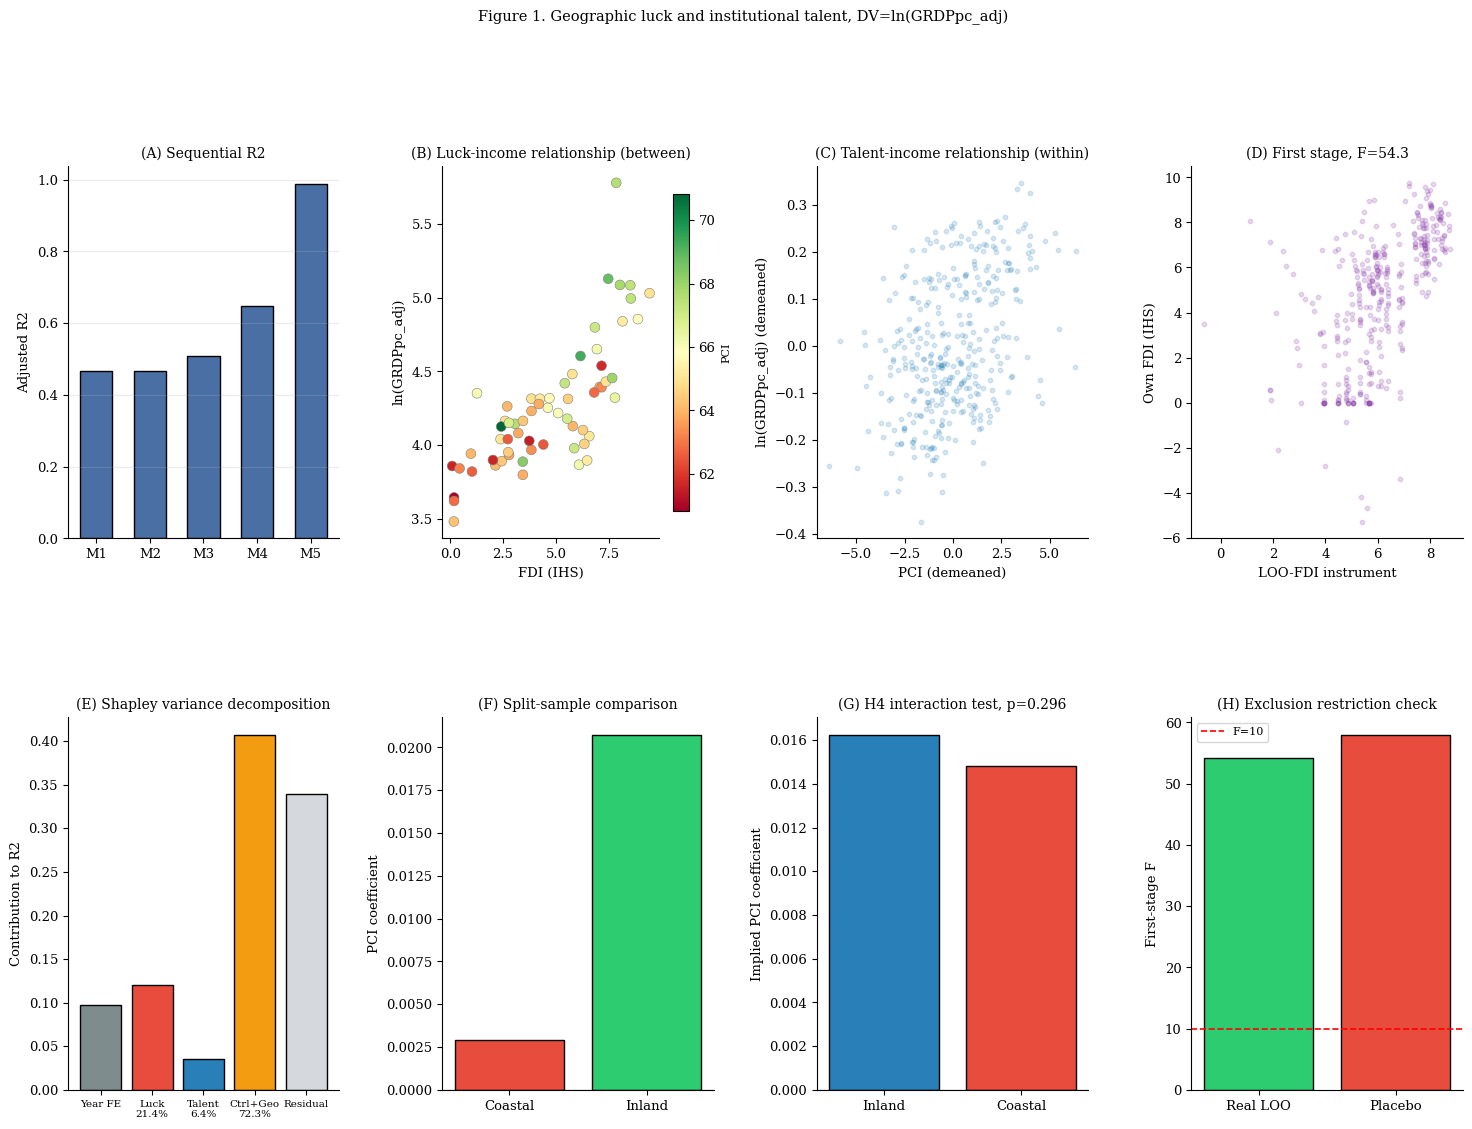

In [8]:
# Figures
dv_label = 'ln(GRDPpc_adj)' if DV == 'lngrdppc_adj' else 'ln(GRDPpc)'

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.48, wspace=0.38)
axes = [fig.add_subplot(gs[i // 4, i % 4]) for i in range(8)]
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes
fig.suptitle(f'Figure 1. Geographic luck and institutional talent, DV={dv_label}', fontsize=10.5, y=1.01)

r2_vals = [seq_fits[k].rsquared_adj for k in seq_specs]
ax1.bar(['M1', 'M2', 'M3', 'M4', 'M5'], r2_vals, color='#4a6fa5', edgecolor='black', width=0.6)
ax1.set_ylabel('Adjusted R2'); ax1.set_title('(A) Sequential R2')
ax1.grid(axis='y', alpha=0.25)

prov_avg = panel_est.groupby('province')[[DV, LUCK, TALENT]].mean().dropna()
sc = ax2.scatter(prov_avg[LUCK], prov_avg[DV], c=prov_avg[TALENT], cmap='RdYlGn', s=50, edgecolor='gray', lw=0.4)
plt.colorbar(sc, ax=ax2, shrink=0.85).set_label('PCI', fontsize=8)
ax2.set_xlabel('FDI (IHS)'); ax2.set_ylabel(dv_label); ax2.set_title('(B) Luck-income relationship (between)')

p_dm = panel_est.copy()
p_dm['grdp_dm'] = p_dm[DV] - p_dm.groupby('province')[DV].transform('mean')
p_dm['pci_dm']  = p_dm[TALENT] - p_dm.groupby('province')[TALENT].transform('mean')
ax3.scatter(p_dm['pci_dm'], p_dm['grdp_dm'], alpha=0.18, s=10, color='#2980b9')
ax3.set_xlabel('PCI (demeaned)'); ax3.set_ylabel(f'{dv_label} (demeaned)'); ax3.set_title('(C) Talent-income relationship (within)')

ax4.scatter(panel_est[INSTR], panel_est[LUCK], alpha=0.2, s=10, color='#8e44ad')
ax4.set_xlabel('LOO-FDI instrument'); ax4.set_ylabel('Own FDI (IHS)'); ax4.set_title(f'(D) First stage, F={F_fs:.1f}')

comp_v = [r2_null, d_luck, d_talent, d_other, 1 - r2_full]
ax5.bar(['Year FE', f'Luck\n{pct_l:.1f}%', f'Talent\n{pct_t:.1f}%',
         f'Ctrl+Geo\n{pct_other:.1f}%', 'Residual'], comp_v,
        color=['#7f8c8d', '#e74c3c', '#2980b9', '#f39c12', '#d5d8dc'], edgecolor='black')
ax5.set_ylabel('Contribution to R2'); ax5.set_title('(E) Shapley variance decomposition')
ax5.tick_params(axis='x', labelsize=7.5)

ax6.bar(['Coastal', 'Inland'], [b_coast_pci, b_inland_pci], color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax6.axhline(0, color='black', lw=0.8); ax6.set_ylabel('PCI coefficient')
ax6.set_title('(F) Split-sample comparison')

ax7.bar(['Inland', 'Coastal'], [b_pci_inland_implied, b_pci_coastal_implied],
        color=['#2980b9', '#e74c3c'], edgecolor='black')
ax7.axhline(0, color='black', lw=0.8); ax7.set_ylabel('Implied PCI coefficient')
ax7.set_title(f'(G) H4 interaction test, p={p_cxp:.3f}')

ax8.bar(['Real LOO', 'Placebo'], [F_real, F_plac], color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax8.axhline(10, color='red', lw=1.2, ls='--', label='F=10')
ax8.set_ylabel('First-stage F'); ax8.set_title('(H) Exclusion restriction check'); ax8.legend(fontsize=8)

plt.savefig('Figure1.png', dpi=250, bbox_inches='tight', facecolor='white')
plt.show()

CELL 8

In [ ]:
# Export
with pd.ExcelWriter('replication_tables.xlsx', engine='openpyxl') as writer:
    t1.round(3).to_excel(writer, sheet_name='T1_Descriptive')

    t2_rows = []
    for v in MAIN_VARS:
        row = {'Variable': DISP.get(v, v)}
        for name, res in seq_fits.items():
            row[name] = fmt(res.params.get(v, np.nan), res.pvalues.get(v, np.nan))
        t2_rows.append(row)
    pd.DataFrame(t2_rows).to_excel(writer, sheet_name='T2_OLS', index=False)

    t3_rows = []
    for v in [LUCK, TALENT, GEO_CTL] + CONTROLS_LM:
        t3_rows.append({'Variable': DISP.get(v, v),
                         'just_id': fmt(m_iv1.params.get(v, np.nan), m_iv1.pvalues.get(v, np.nan)),
                         'over_id': fmt(m_iv3.params.get(v, np.nan), m_iv3.pvalues.get(v, np.nan))})
    pd.DataFrame(t3_rows).to_excel(writer, sheet_name='T3_IV', index=False)

    t4_shapley_rows = [
        {'Component': DISP.get(v, v), 'Shapley_R2': shapley_vals[v],
         'Share_pct': shapley_vals[v] / total_explained * 100} for v in SHAPLEY_VARS
    ]
    t4_shapley_rows += [
        {'Component': 'TOTAL (decomposed vars)', 'Shapley_R2': total_explained, 'Share_pct': 100.0},
        {'Component': 'R2 baseline (year FE only)', 'Shapley_R2': r2_null, 'Share_pct': None},
        {'Component': 'R2 full model', 'Shapley_R2': r2_full, 'Share_pct': None},
    ]
    pd.DataFrame(t4_shapley_rows).to_excel(writer, sheet_name='T4_Shapley_Variance', index=False)

    pd.DataFrame([
        {'Estimator': 'OLS (full)', 'FDI': fmt(seq_fits['(4)'].params.get(LUCK,np.nan), seq_fits['(4)'].pvalues.get(LUCK,np.nan)),
         'PCI': fmt(seq_fits['(4)'].params.get(TALENT,np.nan), seq_fits['(4)'].pvalues.get(TALENT,np.nan)), 'N': N_obs},
        {'Estimator': 'Between', 'FDI': fmt(b_fdi_be, p_fdi_be), 'PCI': fmt(b_pci_be, p_pci_be), 'N': 63},
        {'Estimator': 'Mundlak between', 'FDI': fmt(b_fdi_bw, p_fdi_bw), 'PCI': fmt(b_pci_bw, p_pci_bw), 'N': N_obs},
        {'Estimator': 'Two-way FE', 'FDI': fmt(seq_fits['(5)'].params.get(LUCK,np.nan), seq_fits['(5)'].pvalues.get(LUCK,np.nan)),
         'PCI': fmt(seq_fits['(5)'].params.get(TALENT,np.nan), seq_fits['(5)'].pvalues.get(TALENT,np.nan)), 'N': N_obs},
    ]).to_excel(writer, sheet_name='T6_Mundlak', index=False)

    pd.DataFrame([
        {'Group': 'Coastal', 'N': int(m_coast.nobs), 'PCI': fmt(b_coast_pci, p_coast_pci)},
        {'Group': 'Inland', 'N': int(m_inland.nobs), 'PCI': fmt(b_inland_pci, p_inland_pci)},
    ]).to_excel(writer, sheet_name='T7_SplitSample', index=False)

    pd.DataFrame([
        {'Term': 'PCI (inland, main effect)', 'beta': b_pci_inland_implied, 'p': p_pci_int1},
        {'Term': 'Coastal x PCI (differential)', 'beta': b_cxp, 'p': p_cxp,
         'CI_low': ci_cxp_low, 'CI_high': ci_cxp_high},
        {'Term': 'Implied PCI (coastal)', 'beta': b_pci_coastal_implied, 'p': None},
        {'Term': 'N', 'beta': int(m_int1.nobs), 'p': None},
    ]).to_excel(writer, sheet_name='T8_H4_Interaction', index=False)

    pd.DataFrame([
        {'Test': 'Real LOO first-stage F', 'Value': F_real},
        {'Test': 'Placebo first-stage F', 'Value': F_plac},
        {'Test': 'Placebo coef (both included), p', 'Value': p_plac_in_both},
        {'Test': 'Pooled Pesaran CD, p', 'Value': CD_pool_p},
        {'Test': 'Year x region FE: FDI beta', 'Value': b_fdi_yrfe},
        {'Test': 'Year x region FE: PCI beta', 'Value': b_pci_yrfe},
    ]).to_excel(writer, sheet_name='T9_LOO_Defense', index=False)

    rob_df.to_excel(writer, sheet_name='T10_Robustness', index=False)

    panel_est[['province', 'year', 'region', 'grdppc', 'grdppc_real', 'scoli', 'scoli_filled',
               'lngrdppc', 'lngrdppc_adj']].to_excel(writer, sheet_name='SCOLI_Audit', index=False)

    t12_hist_df = pd.DataFrame([
        {'Item': 'Partial corr(Geo-Luck, PCI | historical_dv)', 'Value': partial_corr_geo_pci, 'p': p_partial},
        {'Item': 'Raw corr(Geo-Luck, PCI) [for comparison]',    'Value': raw_corr_geo_pci, 'p': None},
        {'Item': 'R10: FDI beta (+ historical_dv)',             'Value': m_r10.params.get(LUCK, np.nan), 'p': m_r10.pvalues.get(LUCK, np.nan)},
        {'Item': 'R10: PCI beta (+ historical_dv)',             'Value': m_r10.params.get(TALENT, np.nan), 'p': m_r10.pvalues.get(TALENT, np.nan)},
        {'Item': 'R10: historical_dv beta',                     'Value': m_r10.params.get('historical_dv', np.nan), 'p': m_r10.pvalues.get('historical_dv', np.nan)},
        {'Item': 'R10: adj-R2',                                 'Value': m_r10.rsquared_adj, 'p': None},
        {'Item': 'H4 Coastal x PCI (+ historical_dv)',          'Value': b_cxp_hist, 'p': p_cxp_hist},
        {'Item': 'H4 Coastal x PCI (original, comparison)',     'Value': b_cxp, 'p': p_cxp},
    ])
    t12_hist_df.to_excel(writer, sheet_name='T12_Historical_Robustness', index=False)

    save_cols = ['province', 'year', 'region', 'historical_dv', 'lngrdppc_adj', 'lngrdppc', 'grdppc', 'grdppc_real',
                 'scoli_filled', 'fdi', 'fdi_ihs', 'fdi_loo_ihs', 'fdi_placebo_ihs', 'pci', 'geo_luck',
                 'port_access', 'coastal', 'border', 'trained', 'literacy', 'unemp', 'netmig',
                 'lndensity', 'lnenterprise', STATE_INV_COL]
    panel_est[[c for c in save_cols if c in panel_est.columns]].to_excel(writer, sheet_name='Panel_Data', index=False)

files.download('replication_tables.xlsx')
files.download('Figure1.png')

print(f"\nDone. N={N_obs}, {N_prov} provinces, {N_yr} years.")
print(f"FDI beta (OLS) = {seq_fits['(4)'].params.get(LUCK,np.nan):.4f}, "
      f"PCI beta (OLS) = {seq_fits['(4)'].params.get(TALENT,np.nan):.4f}")
print(f"Luck share (Shapley) = {pct_l:.1f}%, Talent share (Shapley) = {pct_t:.1f}%, "
      f"Controls+Geo share = {pct_other:.1f}%")
print(f"H4 (coastal x PCI) = {b_cxp:.4f}, p = {p_cxp:.4f}, 95% CI [{ci_cxp_low:.4f}, {ci_cxp_high:.4f}]")
print(f"Historical_dv R10: FDI={fmt(m_r10.params.get(LUCK,np.nan), m_r10.pvalues.get(LUCK,np.nan))}, "
      f"PCI={fmt(m_r10.params.get(TALENT,np.nan), m_r10.pvalues.get(TALENT,np.nan))}, "
      f"historical_dv={fmt(m_r10.params.get('historical_dv',np.nan), m_r10.pvalues.get('historical_dv',np.nan))}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. N=378, 63 provinces, 6 years.
FDI beta (OLS) = 0.0355, PCI beta (OLS) = 0.0166
Luck share (Shapley) = 21.4%, Talent share (Shapley) = 6.4%, Controls+Geo share = 72.3%
H4 (coastal x PCI) = -0.0014, p = 0.2957, 95% CI [-0.0041, 0.0012]
Historical_dv R10: FDI=0.0364***, PCI=0.0160**, historical_dv=-0.0397


In [9]:
corr_extra = panel_est[[GEO_CTL, TALENT, LUCK, 'trained', 'unemp', 'netmig',
                         'lndensity', 'lnenterprise', DV, 'historical_dv']].corr()
print(corr_extra['historical_dv'])

geo_luck        -0.029613
pci              0.032192
fdi_ihs          0.203937
trained          0.558876
unemp           -0.020064
netmig           0.298221
lndensity        0.022251
lnenterprise     0.143476
lngrdppc_adj     0.208133
historical_dv    1.000000
Name: historical_dv, dtype: float64
